# 04 — Black-Litterman

**Purpose:** Replace the raw historical mean returns used by `math_optimizer.py` with posterior returns that blend market equilibrium with regime views. Compare BL weights vs current Markowitz weights.

**Depends on:** Run `02_regime_detection.ipynb` first (reads `regime_state.json`). Run `03_factor_model.ipynb` first (reads + updates `factor_state.json`).

**Output:** Adds `bl_returns`, `bl_weights`, `markowitz_weights`, `weight_comparison` to `factor_state.json`

**Sections:**
1. Setup & load regime state
2. Market equilibrium returns
3. Build views from regime
4. BL posterior returns
5. Optimise on BL returns
6. Compare BL vs Markowitz
7. Visualisations
8. Export

In [1]:
import sys, os, json, logging
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR   = os.path.abspath('')
RESEARCH_ROOT  = os.path.join(NOTEBOOK_DIR, '..')
PORTFOLIO_ROOT = os.path.join(RESEARCH_ROOT, '..', '..', 'portfolio')
sys.path.insert(0, PORTFOLIO_ROOT)
sys.path.insert(0, RESEARCH_ROOT)

from src.config import (
    ASSET_UNIVERSE, BENCHMARK_TICKER, LOOKBACK_DAYS, RISK_FREE_RATE,
    OUTPUT_FACTOR, OUTPUT_REGIME,
)
from src.factor_model import (
    compute_market_implied_returns, black_litterman, build_regime_views
)
from src.data_loader import fetch_historical, calculate_log_returns, fetch_fx_rate, convert_usd_prices_to_eur, load_ledger
from src.math_optimizer import run_all_scenarios, optimize_portfolio

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white','axes.grid':True,'grid.alpha':0.3,'font.size':11})
print('✅ Imports OK')

✅ Imports OK


In [2]:
# Load data
CACHE_PATH  = os.path.join(PORTFOLIO_ROOT, 'data', 'historical_prices.csv')
LEDGER_PATH = os.path.join(PORTFOLIO_ROOT, 'data', 'ledger.csv')

prices_raw  = fetch_historical(ASSET_UNIVERSE, LOOKBACK_DAYS, CACHE_PATH)
usd_eur     = fetch_fx_rate('USD', 'EUR')
prices      = convert_usd_prices_to_eur(prices_raw, usd_eur)
log_returns = calculate_log_returns(prices)
holdings, cash = load_ledger(LEDGER_PATH)
held_tickers   = [t for t in holdings.keys() if t in log_returns.columns]

# Use held tickers for BL; fall back to top 20 by data quality
bl_tickers = held_tickers if held_tickers else log_returns.columns[:20].tolist()
print(f'BL universe: {bl_tickers}')

# Load regime state
regime_state = {}
if os.path.exists(OUTPUT_REGIME):
    with open(OUTPUT_REGIME, 'r') as f:
        regime_state = json.load(f)
    print(f'✅ Regime loaded: {regime_state.get("current_regime")} (stress={regime_state.get("stress_score")})')
else:
    print('⚠️  regime_state.json not found — run 02_regime_detection.ipynb first.')
    print('   Defaulting to medium regime with stress_score=0.5')
    regime_state = {'current_regime': 'medium', 'stress_score': 0.5}

INFO: Fetching data for 102 assets from Yahoo Finance...


INFO: Data cached to C:\Users\ahmty\Desktop\hedge-fund\ml_quant_finance_research\general_research\notebooks\..\..\..\portfolio\data\historical_prices.csv (102/102 active tickers)


C:\Users\ahmty\Desktop\hedge-fund\ml_quant_finance_research\general_research\notebooks\..\..\..\portfolio\src\data_loader.py:177: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rate  = float(close.iloc[-1])   # .iloc[-1] avoids FutureWarning from float(Series)
INFO: FX Rate fetched: 1 USD = 0.8482 EUR


INFO:   Converted AMZN: USD → EUR @ 0.8482


INFO:   Converted NVDA: USD → EUR @ 0.8482


...

INFO:   Converted UPS: USD → EUR @ 0.8482


INFO:   Converted DE: USD → EUR @ 0.8482


INFO: Currency conversion applied to 62 non-EUR tickers.


INFO: Ledger loaded. Cash: €150.42, Holdings: 5 assets.


BL universe: ['APC.DE', 'MSF.DE', 'AMZN', 'TSLA', 'ATAI']
✅ Regime loaded: low_stress (stress=0.2753)


## 2. Market equilibrium returns

Reverse-optimises from market weights (approximated as equal-weight here) to imply equilibrium returns. The BL model starts from these rather than raw historical means — which is the key advantage over plain Markowitz.

In [3]:
# Subset returns and cov matrix to BL universe
bl_returns = log_returns[bl_tickers].dropna()
mean_ann   = bl_returns.mean() * 252
cov_ann    = bl_returns.cov()  * 252

# Market weights: use current portfolio weights if available, else equal-weight
if held_tickers:
    latest_prices = prices[held_tickers].iloc[-1]
    raw_values    = {t: holdings[t] * float(latest_prices[t]) for t in held_tickers}
    total_val     = sum(raw_values.values())
    mkt_weights   = pd.Series({t: v/total_val for t, v in raw_values.items()})
    mkt_weights   = mkt_weights.reindex(bl_tickers).fillna(0)
    mkt_weights   = mkt_weights / mkt_weights.sum()  # re-normalise
else:
    mkt_weights = pd.Series(1/len(bl_tickers), index=bl_tickers)

equilibrium_returns = compute_market_implied_returns(cov_ann, mkt_weights, risk_aversion=2.5)

print('Market equilibrium returns (top 10 by magnitude):')
display(equilibrium_returns.sort_values(ascending=False).head(10).rename('Eq. return (ann.)').to_frame())

Market equilibrium returns (top 10 by magnitude):


,Eq. return (ann.)
Ticker,
ATAI,0.639517
TSLA,0.279077
AMZN,0.136216
APC.DE,0.070089
MSF.DE,0.060606


## 3. Build views from regime

The regime model outputs a current stress score. We inject this as a BL view on the benchmark: a high-stress regime implies the benchmark will underperform equilibrium.

In [4]:
current_regime = regime_state.get('current_regime', 'medium')
stress_score   = regime_state.get('stress_score', 0.5)

views = build_regime_views(
    tickers          = bl_tickers,
    benchmark_ticker = BENCHMARK_TICKER,
    regime           = current_regime,
    stress_score     = stress_score,
)

print(f'Regime: {current_regime}  |  Stress: {stress_score}')
if views:
    print(f'Injected view: {views[0]}')
else:
    print('No views injected (benchmark not in BL universe).')

Regime: low_stress  |  Stress: 0.2753
No views injected (benchmark not in BL universe).


## 4. BL posterior returns

In [5]:
posterior_returns = black_litterman(
    cov_matrix     = cov_ann,
    market_weights = mkt_weights,
    views          = views,
    tau            = 0.05,
    risk_aversion  = 2.5,
)

comparison = pd.DataFrame({
    'Equilibrium':    equilibrium_returns,
    'BL Posterior':   posterior_returns,
    'Historical Avg': mean_ann,
}).round(4)
comparison['BL vs Eq. (diff)'] = (comparison['BL Posterior'] - comparison['Equilibrium']).round(4)

print('Return comparison (BL posterior vs equilibrium vs historical):')
display(comparison.sort_values('BL Posterior', ascending=False))

INFO: No views provided — returning equilibrium returns.


Return comparison (BL posterior vs equilibrium vs historical):


,Equilibrium,BL Posterior,Historical Avg,BL vs Eq. (diff)
Ticker,,,,
ATAI,0.6395,0.6395,0.7037,0.0
TSLA,0.2791,0.2791,0.3692,0.0
AMZN,0.1362,0.1362,0.2237,0.0
APC.DE,0.0701,0.0701,0.1287,0.0
MSF.DE,0.0606,0.0606,-0.0375,0.0


## 5. Optimise on BL returns

Run the same max-Sharpe optimizer from `math_optimizer.py` but feeding BL posterior returns instead of raw historical means.

In [6]:
from src.config import MAX_WEIGHT
from src.math_optimizer import optimize_portfolio

bl_opt_weights = optimize_portfolio(posterior_returns, cov_ann, objective='max_sharpe')
bl_weight_series = pd.Series(dict(zip(bl_tickers, bl_opt_weights)))

# Also get standard Markowitz for comparison
mz_opt_weights = optimize_portfolio(mean_ann, cov_ann, objective='max_sharpe')
mz_weight_series = pd.Series(dict(zip(bl_tickers, mz_opt_weights)))

weight_comparison = pd.DataFrame({
    'Markowitz':        mz_weight_series,
    'Black-Litterman':  bl_weight_series,
    'Current (actual)': mkt_weights,
}).round(4)
weight_comparison['BL - Markowitz'] = (weight_comparison['Black-Litterman'] - weight_comparison['Markowitz']).round(4)
weight_comparison = weight_comparison[weight_comparison.sum(axis=1) > 0]  # drop zero rows

print('Weight comparison:')
display(weight_comparison)

Weight comparison:


,Markowitz,Black-Litterman,Current (actual),BL - Markowitz
APC.DE,0.25,0.1932,0.1801,-0.0568
MSF.DE,0.00,0.1794,0.1716,0.1794
AMZN,0.25,0.1918,0.1682,-0.0582
TSLA,0.25,0.1856,0.1799,-0.0644
ATAI,0.25,0.2500,0.3003,0.0000


## 6 & 7. Visualisations

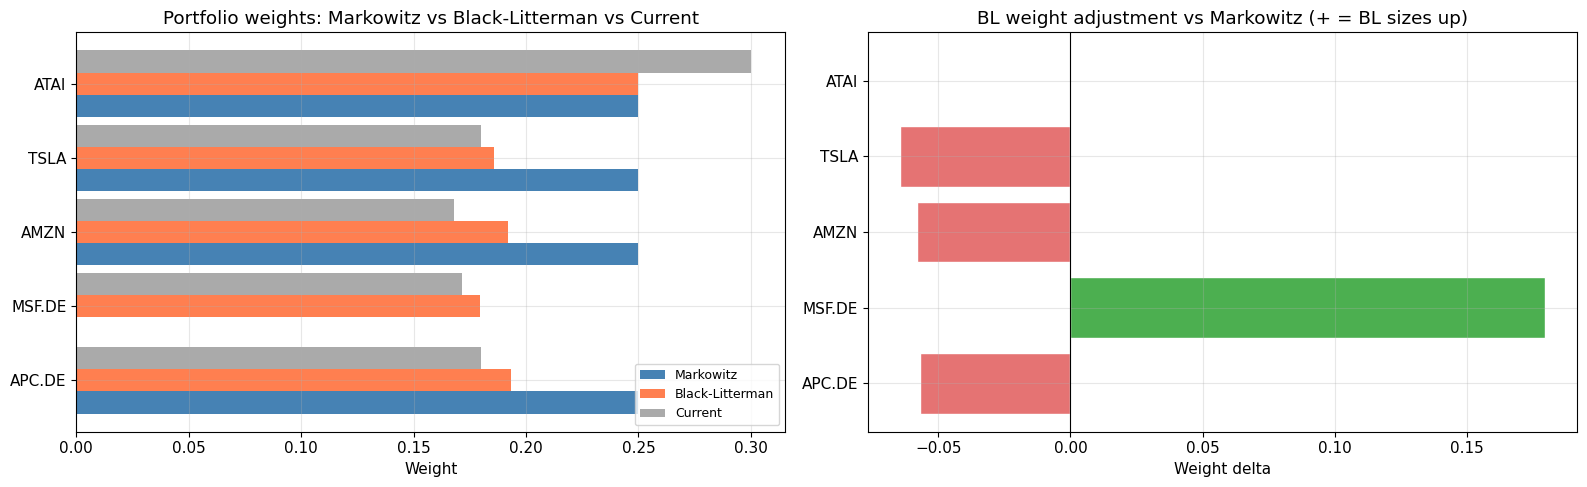

In [7]:
if len(bl_tickers) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(bl_tickers)*0.5)))

    # Weight comparison
    x = np.arange(len(weight_comparison))
    w = 0.3
    axes[0].barh(x,       weight_comparison['Markowitz'],       w, label='Markowitz',       color='steelblue',  left=0)
    axes[0].barh(x + w,   weight_comparison['Black-Litterman'], w, label='Black-Litterman', color='coral',      left=0)
    axes[0].barh(x + 2*w, weight_comparison['Current (actual)'],w, label='Current',         color='#aaa',       left=0)
    axes[0].set_yticks(x + w)
    axes[0].set_yticklabels(weight_comparison.index)
    axes[0].set_xlabel('Weight')
    axes[0].set_title('Portfolio weights: Markowitz vs Black-Litterman vs Current')
    axes[0].legend(fontsize=9)

    # BL - Markowitz delta
    delta = weight_comparison['BL - Markowitz']
    colors = ['#4CAF50' if v > 0 else '#E57373' for v in delta]
    axes[1].barh(weight_comparison.index, delta, color=colors, edgecolor='white')
    axes[1].axvline(0, color='black', linewidth=0.8)
    axes[1].set_title('BL weight adjustment vs Markowitz (+ = BL sizes up)')
    axes[1].set_xlabel('Weight delta')

    plt.tight_layout()
    plt.show()

## 8. Export

In [8]:
# Load existing factor_state (written by NB 03) and add BL data
existing = {}
if os.path.exists(OUTPUT_FACTOR):
    with open(OUTPUT_FACTOR, 'r') as f:
        existing = json.load(f)

existing.update({
    'bl_generated_at':      datetime.now().isoformat(),
    'regime_used':          current_regime,
    'stress_score_used':    stress_score,
    'bl_views':             views,
    'equilibrium_returns':  equilibrium_returns.round(6).to_dict(),
    'bl_posterior_returns': posterior_returns.round(6).to_dict(),
    'bl_weights':           bl_weight_series.round(4).to_dict(),
    'markowitz_weights':    mz_weight_series.round(4).to_dict(),
    'current_weights':      mkt_weights.round(4).to_dict(),
    'weight_comparison':    weight_comparison.reset_index().rename(columns={'index':'ticker'}).where(pd.notna(weight_comparison.reset_index()), None).to_dict(orient='records'),
})

with open(OUTPUT_FACTOR, 'w', encoding='utf-8') as f:
    json.dump(existing, f, indent=2, default=str)

print(f'✅ Exported → {OUTPUT_FACTOR}  ({os.path.getsize(OUTPUT_FACTOR)/1024:.1f} KB)')
print('   factor_state.json now contains both factor regressions AND BL weights.')

✅ Exported → C:\Users\ahmty\Desktop\hedge-fund\ml_quant_finance_research\general_research\notebooks\..\src\..\outputs\factor_state.json  (3.6 KB)
   factor_state.json now contains both factor regressions AND BL weights.
